# Task 5: Advanced Analysis
Objective: To perform deeper churn analysis across tenure groups, demographics, contract types, and payment methods.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../Telco_Customer_Churn_Dataset  (3).csv")

# Basic cleaning
df.columns = df.columns.str.lower().str.replace(" ", "_")
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')
df['totalcharges'] = df['totalcharges'].fillna(df['totalcharges'].median())


In [2]:
bins = [0, 12, 36, 72]
labels = ['0-12 Months', '13-36 Months', '37+ Months']

df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels)


In [3]:
pd.crosstab(df['tenure_group'], df['churn'], normalize='index') * 100


churn,No,Yes
tenure_group,,
0-12 Months,52.321839,47.678161
13-36 Months,74.461207,25.538793
37+ Months,88.070643,11.929357


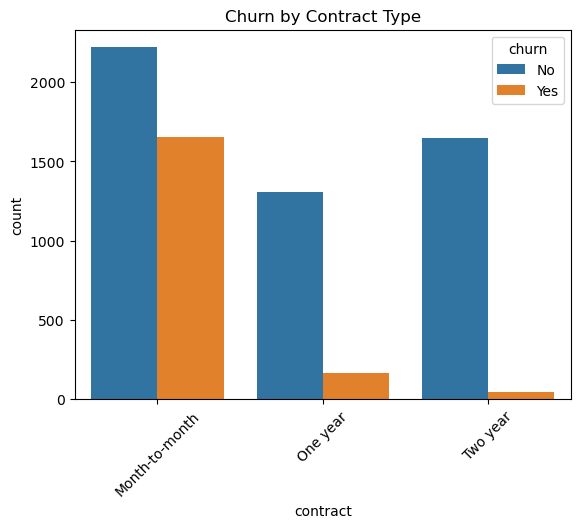

In [4]:
sns.countplot(x='contract', hue='churn', data=df)
plt.xticks(rotation=45)
plt.title("Churn by Contract Type")
plt.savefig("contract_churn.png")
plt.show()


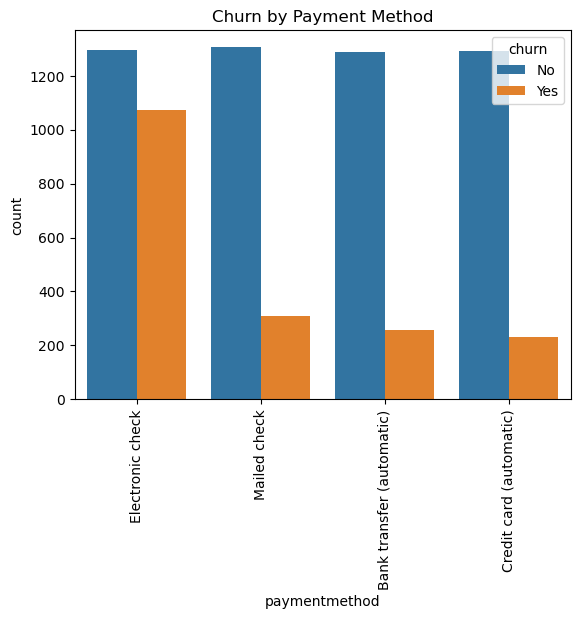

In [5]:
sns.countplot(x='paymentmethod', hue='churn', data=df)
plt.xticks(rotation=90)
plt.title("Churn by Payment Method")
plt.savefig("payment_method_churn.png")
plt.show()


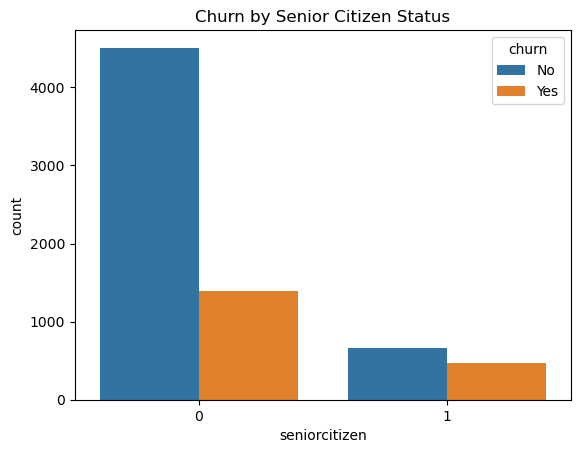

In [6]:
sns.countplot(x='seniorcitizen', hue='churn', data=df)
plt.title("Churn by Senior Citizen Status")
plt.savefig("seniorcitizen_churn.png")
plt.show()


In [7]:
df.groupby('tenure_group')[['monthlycharges','totalcharges']].mean()


C:\Users\shubh\AppData\Local\Temp\ipykernel_10152\566590432.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tenure_group')[['monthlycharges','totalcharges']].mean()


,monthlycharges,totalcharges
tenure_group,,
0-12 Months,56.172023,276.621563
13-36 Months,63.248195,1513.541756
37+ Months,72.008730,4213.723192


## Advanced Analysis Insights

- Customers with month-to-month contracts show the highest churn rate.
- Electronic check payment method has higher churn proportion.
- Short tenure customers (0-12 months) exhibit higher churn rates.
- Senior citizens show distinct churn behavior compared to non-senior customers.
- Long-term customers contribute significantly to total revenue.
